In [1]:
import os
import random
import shutil
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits

# Definir los directorios de origen y destino
src_folder = "spectrums"
dst_folder = "spectrums training 100k"

# Crear la carpeta de destino si no existe
if not os.path.exists(dst_folder):
    os.makedirs(dst_folder)

# Listar todos los archivos .fits en el directorio de origen
fits_files = [f for f in os.listdir(src_folder) if f.lower().endswith(".fits")]

# Seleccionar 100000 archivos aleatorios
selected_files = random.sample(fits_files, 100000)

# Definir los rangos de redshift deseados
bin_ranges = [(0, 0.1), (0.1, 1), (1, 2), (2, 3), (3, 4), (4, 5), (5, 6), (6, 7), (7, 8)]

# Diccionario para llevar el conteo en cada rango
bin_counts = {br: 0 for br in bin_ranges}

# Diccionario con mínimos distintos para cada rango
# 0-1 hay > 100000
# 1-2 hay > 100000
# 2-3 hay > 100000
# 3-4 hay 35894
# 4-5 hay 2529
# 5-6 hay 900
# 6-7 hay 854
# 7-8 hay 245

min_required_values = {
    (0, 0.1): 20000,
    (0.1, 1): 15000,
    (1, 2): 20000,
    (2, 3): 15000,
    (3, 4): 5000,
    (4, 5): 2000,
    (5, 6): 900,
    (6, 7): 850,
    (7, 8): 240
}

# Lista para almacenar los valores de redshift y usarlos en el histograma
redshift_values = []

# Copiar archivos y extraer el valor de redshift de cada uno
for file in selected_files:
    src_path = os.path.join(src_folder, file)
    dst_path = os.path.join(dst_folder, file)
    
    # Verificar si el archivo existe, de lo contrario saltarlo
    if not os.path.exists(src_path):
        print(f"Archivo no encontrado: {file}. Saltando.")
        continue
    
    # Copiar el archivo
    shutil.copy(src_path, dst_path)
    print(f"Copiado: {file}")
    
    # Extraer el valor de redshift
    try:
        with fits.open(src_path) as hdul:
            redshift = hdul[2].data["Z"][0]
            redshift_values.append(redshift)
            # Determinar en qué rango cae el redshift y actualizar el conteo
            for br in bin_ranges:
                lower, upper = br
                if lower <= redshift < upper:
                    bin_counts[br] += 1
                    break
    except Exception as e:
        print(f"Error procesando {file}: {e}")

# Imprimir un reporte individual para cada rango con su mínimo respectivo
print("\nConteo por rangos de redshift:")
for br in bin_ranges:
    lower, upper = br
    count = bin_counts[br]
    min_required = min_required_values.get(br, 0)
    if count >= min_required:
        print(f"Rango {lower} - {upper}: {count} archivos (cumple con el mínimo de {min_required})")
    else:
        print(f"Rango {lower} - {upper}: {count} archivos (NO cumple con el mínimo de {min_required})")

Copiado: spec-9216-57693-0947.fits
Copiado: spec-7158-56956-0921.fits
Copiado: spec-2603-54479-0304.fits
Copiado: spec-6663-56338-0469.fits
Copiado: spec-5372-55978-0393.fits
Copiado: spec-5047-55833-0357.fits
Copiado: spec-0792-52353-0280.fits
Copiado: spec-6632-56366-0529.fits
Copiado: spec-0665-52168-0247.fits
Copiado: spec-3677-55205-0677.fits
Copiado: spec-1280-52738-0529.fits
Copiado: spec-0898-52606-0195.fits
Copiado: spec-6205-56187-0788.fits
Copiado: spec-4398-55946-0424.fits
Copiado: spec-11329-58426-0576.fits
Copiado: spec-4205-55454-0139.fits
Copiado: spec-11053-58437-0159.fits
Copiado: spec-8516-58220-0365.fits
Copiado: spec-1829-53494-0156.fits
Copiado: spec-5201-55832-0983.fits
Copiado: spec-4723-56033-0120.fits
Copiado: spec-4296-55499-0878.fits
Copiado: spec-6051-56093-0675.fits
Copiado: spec-6385-56356-0603.fits
Copiado: spec-9409-58051-0345.fits
Copiado: spec-8494-57104-0128.fits
Copiado: spec-6659-56607-0301.fits
Copiado: spec-0595-52023-0081.fits
Copiado: spec-0615

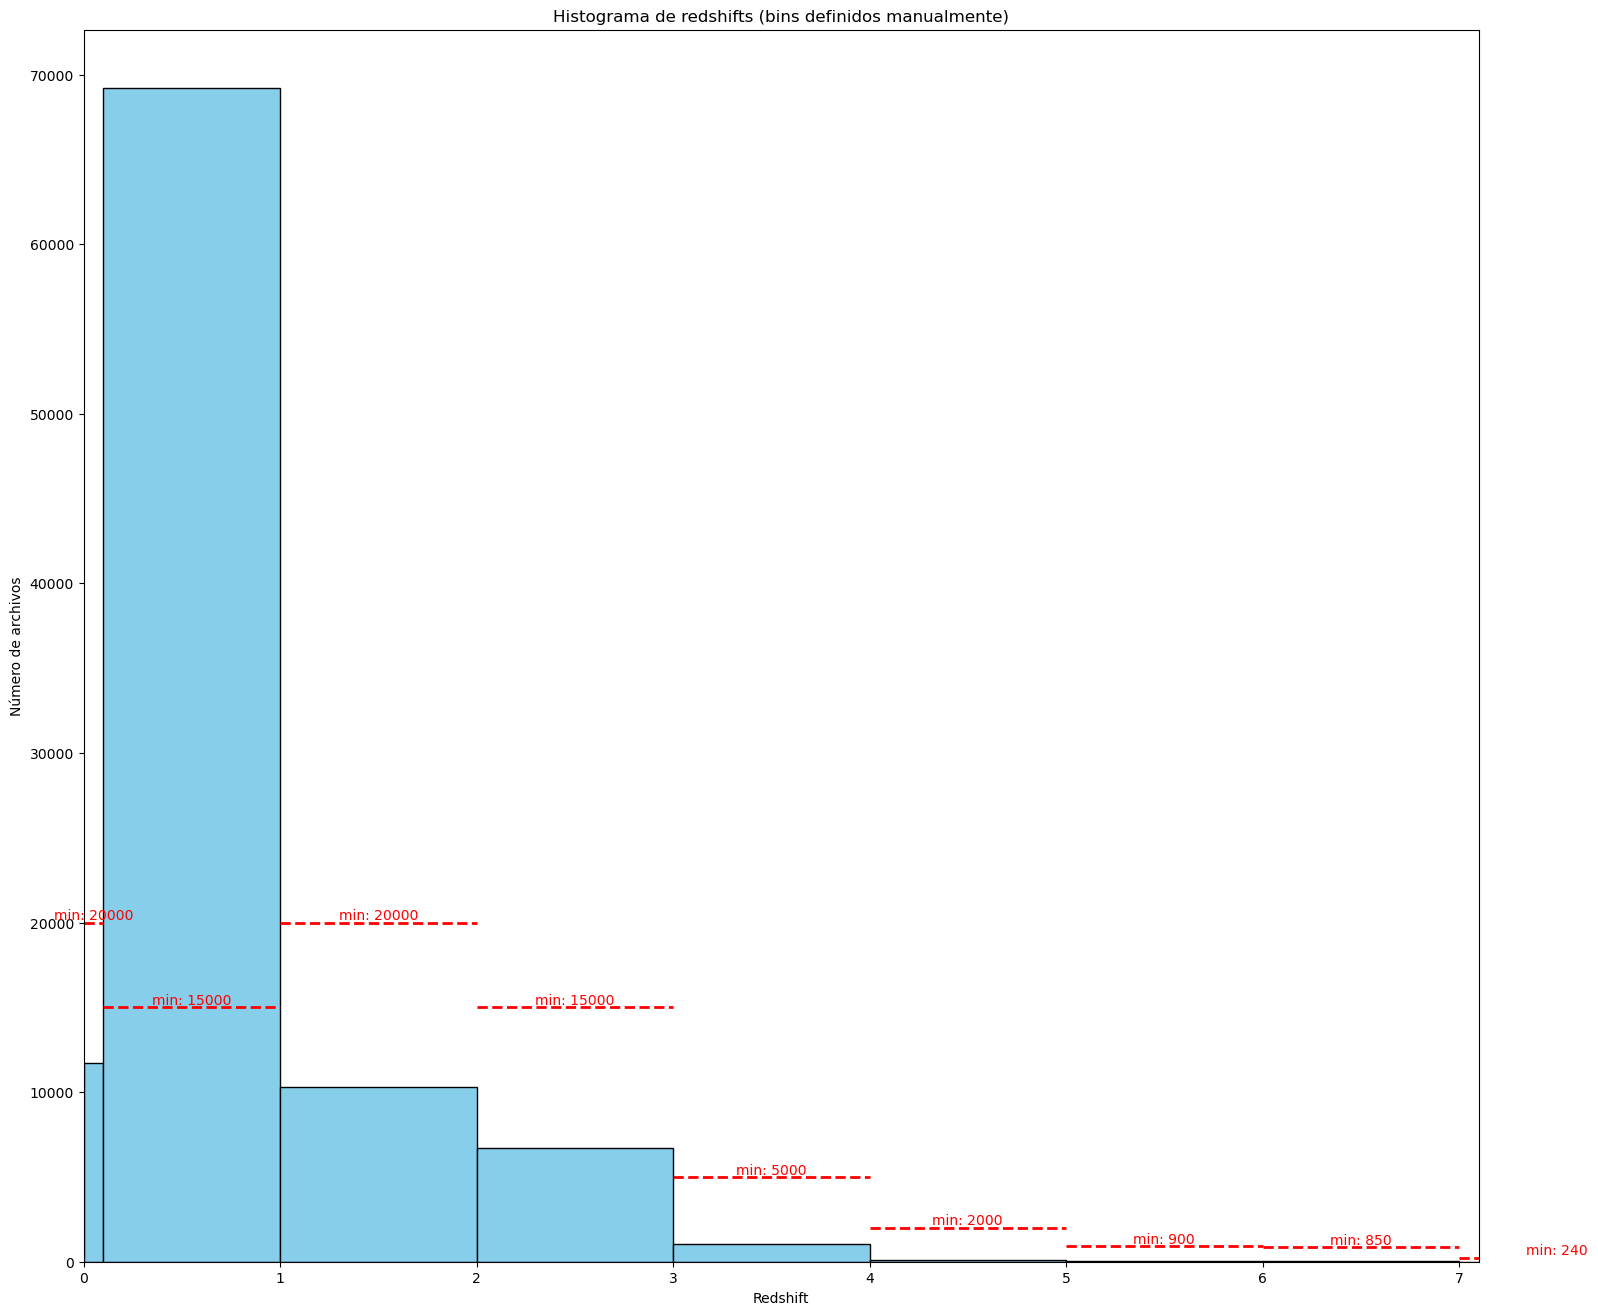

In [ ]:
# Definir los bordes de los bins para el histograma usando los rangos definidos
bin_edges = [br[0] for br in bin_ranges] + [bin_ranges[-1][1]]

# Crear el histograma
plt.figure(figsize=(18,16))
n, bins_hist, patches = plt.hist(redshift_values, bins=bin_edges, color='skyblue', edgecolor='black')
plt.xlabel("Redshift")
plt.ylabel("Número de archivos")
plt.title("Histograma de redshifts (bins definidos manualmente)")

# Conteo por rangos de redshift:
# Rango 0 - 0.1: 11747 archivos (NO cumple con el mínimo de 20000)
# Rango 0.1 - 1: 69185 archivos (cumple con el mínimo de 15000)
# Rango 1 - 2: 10313 archivos (NO cumple con el mínimo de 20000)
# Rango 2 - 3: 6696 archivos (NO cumple con el mínimo de 15000)
# Rango 3 - 4: 1034 archivos (NO cumple con el mínimo de 5000)
# Rango 4 - 5: 74 archivos (NO cumple con el mínimo de 2000)
# Rango 5 - 6: 29 archivos (NO cumple con el mínimo de 900)
# Rango 6 - 7: 28 archivos (NO cumple con el mínimo de 850)
# Rango 7 - 8: 9 archivos (NO cumple con el mínimo de 240)

# Dibujar líneas horizontales de referencia para cada rango con el mínimo requerido
for br in bin_ranges:
    lower, upper = br
    min_required = min_required_values.get(br, 0)
    # Dibujar una línea horizontal que cubre el rango del bin
    plt.hlines(y=min_required, xmin=lower, xmax=upper, colors='red', linestyles='dashed', linewidth=2)
    # Anotar el valor mínimo en el centro del rango
    x_center = (lower + upper) / 2
    plt.text(x_center, min_required + 1, f"min: {min_required}", color='red', ha='center', va='bottom')

plt.xlim(0, 7.1)
plt.show()

In [ ]:
import os
from astropy.io import fits

# Definir el directorio que contiene los archivos FITS
src_folder = "spectrums training 100k"

# Recorrer todos los archivos en el directorio de origen
for file in os.listdir(src_folder):
    if file.lower().endswith(".fits"):
        file_path = os.path.join(src_folder, file)
        try:
            with fits.open(file_path) as hdul:
                redshift = hdul[2].data["Z"][0]
                # Verificar si el redshift está en el rango 0.1 <= z < 1
                if 0.1 <= redshift < 1:
                    os.remove(file_path)
                    print(f"Eliminado: {file}")
        except Exception as e:
            print(f"Error procesando {file}: {e}")

print("Proceso de eliminación completado.")


Error procesando spec-0266-51630-0097.fits: [WinError 32] The process cannot access the file because it is being used by another process: 'spectrums training 100k\\spec-0266-51630-0097.fits'
Error procesando spec-0266-51630-0210.fits: [WinError 32] The process cannot access the file because it is being used by another process: 'spectrums training 100k\\spec-0266-51630-0210.fits'
Error procesando spec-0266-51630-0303.fits: [WinError 32] The process cannot access the file because it is being used by another process: 'spectrums training 100k\\spec-0266-51630-0303.fits'
Error procesando spec-0266-51630-0305.fits: [WinError 32] The process cannot access the file because it is being used by another process: 'spectrums training 100k\\spec-0266-51630-0305.fits'
Error procesando spec-0266-51630-0428.fits: [WinError 32] The process cannot access the file because it is being used by another process: 'spectrums training 100k\\spec-0266-51630-0428.fits'
Error procesando spec-0266-51630-0442.fits: [